<a href="https://colab.research.google.com/github/1Bur1/Tuwaiq-classes---advanced-AI-python---final-project/blob/main/01_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [25]:
#task 1
#• Load the data using pd.read_csv() and print the first 5 rows


import pandas as pd

df = pd.read_csv("AmesHousing.csv")
df.head() # print the first 5 rows

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [26]:
#task 2
#• Check the shape: how many rows and columns?


df.shape #Check the shape: how many rows and columns?

(2930, 82)

In [27]:
df.info()
#are any columns the wrong type?
#yes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [39]:
#task 3
#• Inspect data types: use .info() — are any columns the wrong type? Fix at least 2


import pandas as pd
import numpy as np

df = pd.read_csv("AmesHousing.csv")







# Converted "Bsmt Full Bath", "Bsmt Half Bath", and "Garage Cars"
# from float to Int64 because they represent count-based numeric values with possible missing data.
numeric_fix_cols = [
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Garage Cars"
]

for col in numeric_fix_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


for col in numeric_fix_cols:
    df[col] = df[col].astype("Int64")










# Converted "Year Built", "Year Remod/Add", "Garage Yr Blt", and "Yr Sold"
# from int/float to datetime because they represent time (years) rather than continuous numeric values.
year_cols = [
    "Year Built",
    "Year Remod/Add",
    "Garage Yr Blt",
    "Yr Sold"
]

for col in year_cols:
    df[col] = pd.to_datetime(df[col], format="%Y", errors="coerce")








# Converted "Order", "PID", and "MS SubClass"
# from int to category because they are identifiers or coded categories, not meaningful numeric features.
category_fix_cols = [
    "Order",#identifiers
    "PID",#identifiers
    "MS SubClass",#coded
    "Overall Qual",#rate level
    "Overall Cond"#rate level

]

for col in category_fix_cols:
    df[col] = df[col].astype("category")







#because of the type  object it use unneeded amount of memiory
#convert to category
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order            2930 non-null   category      
 1   PID              2930 non-null   category      
 2   MS SubClass      2930 non-null   category      
 3   MS Zoning        2930 non-null   category      
 4   Lot Frontage     2440 non-null   float64       
 5   Lot Area         2930 non-null   int64         
 6   Street           2930 non-null   category      
 7   Alley            198 non-null    category      
 8   Lot Shape        2930 non-null   category      
 9   Land Contour     2930 non-null   category      
 10  Utilities        2930 non-null   category      
 11  Lot Config       2930 non-null   category      
 12  Land Slope       2930 non-null   category      
 13  Neighborhood     2930 non-null   category      
 14  Condition 1      2930 non-null   categor

In [40]:
# task 4
#Find missing values: use .isnull().sum() — which columns have the most? Decide what todo (fill in or drop) and explain why



# detect missing
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)
print(missing[missing > 0].head(10))  # columns with the most missing values









# drop the Columns with  high missings
drop_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence']


# Filter drop_cols to only include columns that are actually in df.columns
existing_drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=existing_drop_cols)












# Categorical columns were filled using the mode to preserve the most used category
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])







# Numeric columns were filled using the median to handle skewed distributions
num_cols = df.select_dtypes(include=['int64', 'float64', 'Int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())




# fill datetime columns with mode
date_cols = df.select_dtypes(include=['datetime64[ns]']).columns
for col in date_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
                  ... 
Mo Sold              0
Yr Sold              0
Sale Type            0
Sale Condition       0
SalePrice            0
Length: 82, dtype: int64
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64


In [30]:
#Task 5
#• Handle duplicates: check with .duplicated().sum() and remove if any

print(df.duplicated().sum())

df = df.drop_duplicates() #maybe we will need it in another data
#there is no duplicates


0


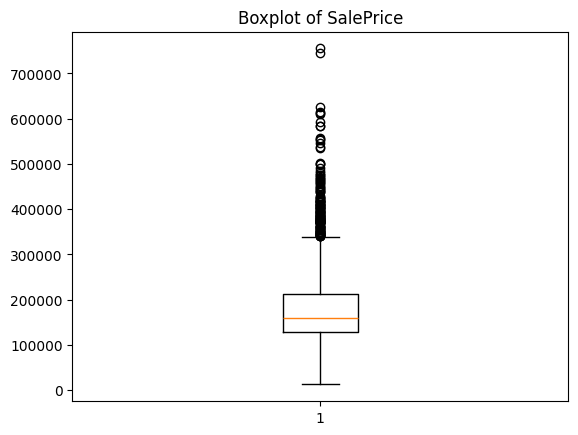

In [31]:
#task 6
#Spot outliers: use a boxplot or the IQR method on the target column; cap extreme values at the 99th percentile


import matplotlib.pyplot as plt





# Boxplot
plt.boxplot(df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.show()



# Cap at 99th percentile
upper_99 = df["SalePrice"].quantile(0.99)
df["SalePrice" + "_capped"] = df["SalePrice"].clip(upper=upper_99)



(2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  Hou

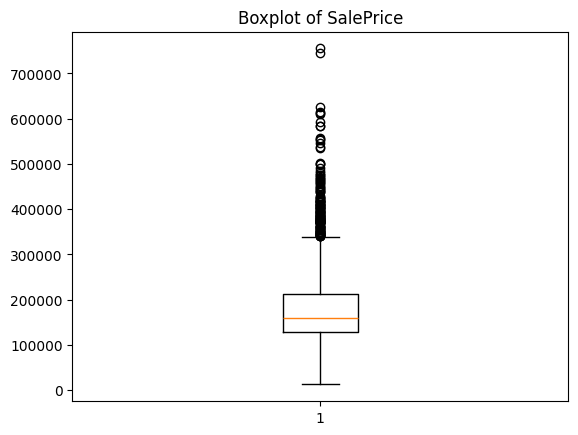

In [45]:
#task 7
#write a clean_data() function that does all the above steps in order so you can reuse it



def clean_data(df):
  df = df.copy()

  #task1
  print(df.shape)
  #task2
  df.info()

  #task3
  # Converted "Bsmt Full Bath", "Bsmt Half Bath", and "Garage Cars"
  # from float to Int64 because they represent count-based numeric values with possible missing data.
  numeric_fix_cols = [
      "Bsmt Full Bath",
      "Bsmt Half Bath",
      "Garage Cars"
    ]

  for col in numeric_fix_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

  for col in numeric_fix_cols:
    df[col] = df[col].astype("Int64")







# Converted "Year Built", "Year Remod/Add", "Garage Yr Blt", and "Yr Sold"
# from int/float to datetime because they represent time (years) rather than continuous numeric values.
  year_cols = [
      "Year Built",
      "Year Remod/Add",
      "Garage Yr Blt",
      "Yr Sold"
  ]

  for col in year_cols:
      df[col] = pd.to_datetime(df[col], format="%Y", errors="coerce")








# Converted "Order", "PID", and "MS SubClass"
# from int to category because they are identifiers or coded categories, not meaningful numeric features.
  category_fix_cols = [
      "Order",#identifiers
      "PID",#identifiers
      "MS SubClass",#coded
      "Overall Qual",#rate level
      "Overall Cond"#rate level

  ]

  for col in category_fix_cols:
      df[col] = df[col].astype("category")







#because of the type  object it use unneeded amount of memiory
#convert to category
  cat_cols = df.select_dtypes(include='object').columns

  for col in cat_cols:
      df[col] = df[col].astype('category')

  df.info()






#task4
# detect missing
  missing = df.isnull().sum().sort_values(ascending=False)
  print(missing)
  print(missing[missing > 0].head(10))  # columns with the most missing values









# drop the Columns with  high missings
  drop_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence']


# Filter drop_cols to only include columns that are actually in df.columns * i put it because of an error
  existing_drop_cols = [col for col in drop_cols if col in df.columns]
  df = df.drop(columns=existing_drop_cols)












# Categorical columns were filled using the mode to preserve the most used category
  cat_cols = df.select_dtypes(include=['object', 'category']).columns

  for col in cat_cols:
      df[col] = df[col].fillna(df[col].mode()[0])







# Numeric columns were filled using the median to handle skewed distributions
  num_cols = df.select_dtypes(include=['int64', 'float64', 'Int64']).columns

  for col in num_cols:
      df[col] = df[col].fillna(df[col].median())


  # fill datetime columns with mode
  date_cols = df.select_dtypes(include=['datetime64[ns]']).columns
  for col in date_cols:
      df[col] = df[col].fillna(df[col].mode()[0])






  #Task 5
  #• Handle duplicates: check with .duplicated().sum() and remove if any

  print(df.duplicated().sum())

  df = df.drop_duplicates() #maybe we will need it in another data




  #task 6
  #Spot outliers: use a boxplot or the IQR method on the target column; cap extreme values at the 99th percentile


  import matplotlib.pyplot as plt





  # Boxplot
  plt.boxplot(df["SalePrice"])
  plt.title("Boxplot of SalePrice")
  plt.show()



  # Cap at 99th percentile
  upper_99 = df["SalePrice"].quantile(0.99)
  df["SalePrice" + "_capped"] = df["SalePrice"].clip(upper=upper_99)




  #task 8
# Add 3 checks at the end (e.g., no nulls in key columns, all target values > 0, correct number of columns)



# No nulls
  assert df["SalePrice"].isnull().sum() == 0

# Target values must be positive
  assert (df["SalePrice"] > 0).all()

# Ensure column exists
  assert "SalePrice" in df.columns

  return df

df = pd.read_csv("AmesHousing.csv")
df_clean = clean_data(df)
